In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# New Section

In [ ]:
data_dir = "/content/drive/MyDrive/Garbage classification dataset"


In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as preprocess_input_resnet
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix


In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input_resnet,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input_resnet,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # VERY IMPORTANT
)

class_names = list(train_data.class_indices.keys())
num_classes = train_data.num_classes

print("Classes:", class_names)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
train_labels = train_data.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.04437564499484), 1: np.float64(0.8412302576891105), 2: np.float64(1.0284552845528456), 3: np.float64(0.7086834733893558), 4: np.float64(0.8739205526770294), 5: np.float64(3.066666666666667)}


In [ ]:
resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet.trainable = False

model = Sequential([
    resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [ ]:
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]

)

print("Training completed!")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.5810 - loss: 1.2701

64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 771ms/step - accuracy: 0.5829 - loss: 1.2642 - val_accuracy: 0.7654 - val_loss: 0.6018
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8266 - loss: 0.4653

64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 540ms/step - accuracy: 0.8267 - loss: 0.4648 - val_accuracy: 0.8032 - val_loss: 0.5715
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 529ms/step - accuracy: 0.8695 - loss: 0.3452 - val_accuracy: 0.7992 - val_loss: 0.6047
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 537ms/step - accuracy: 0.8924 - loss: 0.2615 - val_accuracy: 0.7952 - val_loss: 0.6350
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9189 - loss: 0.2048

64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 529ms/step - accuracy: 0.9189 - loss: 0.2051 - val_accuracy: 0.8270 - val_loss: 0.4574
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 545ms/step - accuracy: 0.9364 - loss: 0.2000 - val_accuracy: 0.8131 - val_loss: 0.6382
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9316 - loss: 0.1792

64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 532ms/step - accuracy: 0.9315 - loss: 0.1792 - val_accuracy: 0.8290 - val_loss: 0.4884
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9417 - loss: 0.1371

64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 549ms/step - accuracy: 0.9419 - loss: 0.1370 - val_accuracy: 0.8350 - val_loss: 0.5541
Epoch 9/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9614 - loss: 0.1057

64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 549ms/step - accuracy: 0.9612 - loss: 0.1059 - val_accuracy: 0.8489 - val_loss: 0.4483
Epoch 10/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.9570 - loss: 0.1065 - val_accuracy: 0.8330 - val_loss: 0.4964
Epoch 11/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 545ms/step - accuracy: 0.9685 - loss: 0.0969 - val_accuracy: 0.8449 - val_loss: 0.5472
Epoch 12/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.9570 - loss: 0.1001 - val_accuracy: 0.8489 - val_loss: 0.4647
Epoch 13/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 551ms/step - accuracy: 0.9625 - loss: 0.0904 - val_accuracy: 0.8310 - val_loss: 0.6831
Training completed!


16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 417ms/step

Accuracy: 0.8489
Precision: 0.8536
Recall: 0.8489
F1-Score: 0.8465


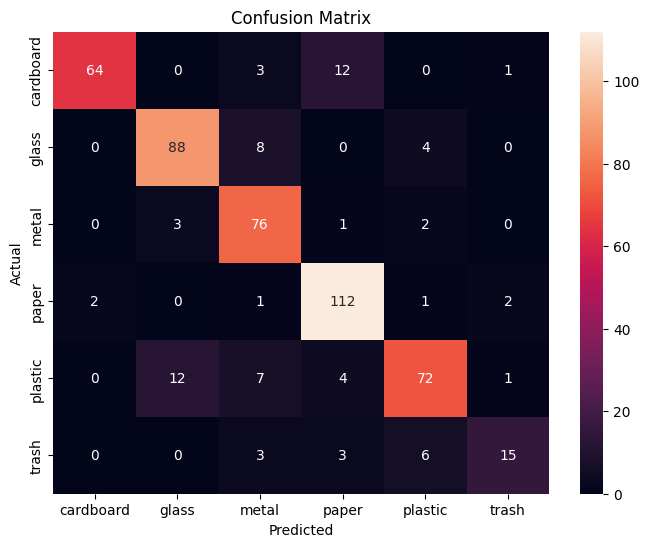

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Unfreeze the top 30 layers of ResNet
for layer in resnet.layers[-30:]:
    layer.trainable = True


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # small LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

# ---- Metrics ----
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Save final model
model.save(
    "updated_model.keras",
    include_optimizer=False
)

print("Model saved as updated_model.keras")


from google.colab import files
files.download("updated_model.keras")





MOBILENET

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
num_classes = train_data.num_classes


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
train_labels = train_data.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
checkpoint = ModelCheckpoint(
    "mobilenet_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.5090 - loss: 1.4661

64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 964ms/step - accuracy: 0.5109 - loss: 1.4599 - val_accuracy: 0.7117 - val_loss: 0.7263
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8123 - loss: 0.5549

64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 522ms/step - accuracy: 0.8122 - loss: 0.5550 - val_accuracy: 0.7674 - val_loss: 0.6206
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.8445 - loss: 0.4241

64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 511ms/step - accuracy: 0.8444 - loss: 0.4243 - val_accuracy: 0.7853 - val_loss: 0.5684
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8685 - loss: 0.3403

64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 516ms/step - accuracy: 0.8684 - loss: 0.3405 - val_accuracy: 0.7893 - val_loss: 0.5989
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8882 - loss: 0.2944

64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 522ms/step - accuracy: 0.8881 - loss: 0.2948 - val_accuracy: 0.7932 - val_loss: 0.6032
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9010 - loss: 0.2720

64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 515ms/step - accuracy: 0.9011 - loss: 0.2720 - val_accuracy: 0.7952 - val_loss: 0.5812
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.8893 - loss: 0.2830

64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 514ms/step - accuracy: 0.8894 - loss: 0.2830 - val_accuracy: 0.7972 - val_loss: 0.5662
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 517ms/step - accuracy: 0.9153 - loss: 0.2358 - val_accuracy: 0.7694 - val_loss: 0.6969
Epoch 9/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.9139 - loss: 0.2139 - val_accuracy: 0.7873 - val_loss: 0.6143
Epoch 10/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 526ms/step - accuracy: 0.9329 - loss: 0.1636 - val_accuracy: 0.7833 - val_loss: 0.6803
Epoch 11/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.9459 - loss: 0.1351 - val_accuracy: 0.7932 - val_loss: 0.7107


16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 406ms/step

Accuracy: 0.7972
Precision: 0.8078
Recall: 0.7972
F1-Score: 0.7997


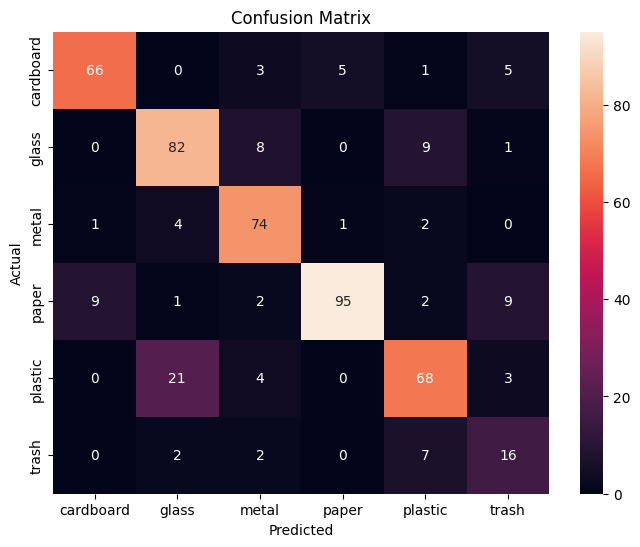

In [ ]:
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, validation_data=val_data, epochs=5)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

# ---- Metrics ----
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


EFFICIENTNETB0

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [ ]:
mixed_precision.set_global_policy("mixed_float16")


In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
num_classes = train_data.num_classes


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
train_labels = train_data.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))


In [ ]:
base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_eff.trainable = False

model_eff = Sequential([
    base_model_eff,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_eff.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
checkpoint = ModelCheckpoint(
    "efficientnet_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.6095 - loss: 1.0615 - val_accuracy: 0.7972 - val_loss: 0.5512
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 528ms/step - accuracy: 0.8556 - loss: 0.3805 - val_accuracy: 0.8350 - val_loss: 0.5013
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.8991 - loss: 0.2773 - val_accuracy: 0.8529 - val_loss: 0.4249
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.9363 - loss: 0.1871 - val_accuracy: 0.8549 - val_loss: 0.4291
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 507ms/step - accuracy: 0.9386 - loss: 0.1659 - val_accuracy: 0.8588 - val_loss: 0.4475
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.9490 - loss: 0.1411 - val_accuracy: 0.8588 - val_loss: 0.4386
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 500ms/step - accuracy: 0.9706 - loss: 0.1052 - val_accuracy: 0.8370 - val_loss: 0.4804


In [ ]:
model_eff.save("effb0_model.keras")

In [ ]:
import os
print(os.listdir())

['.config', 'efficientnet_best.h5', 'effb0_model.keras', 'drive', 'efficientnet_best.keras', 'eff_model.keras', 'sample_data']


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step

Accuracy: 0.8827
Precision: 0.8895
Recall: 0.8827
F1-Score: 0.8837


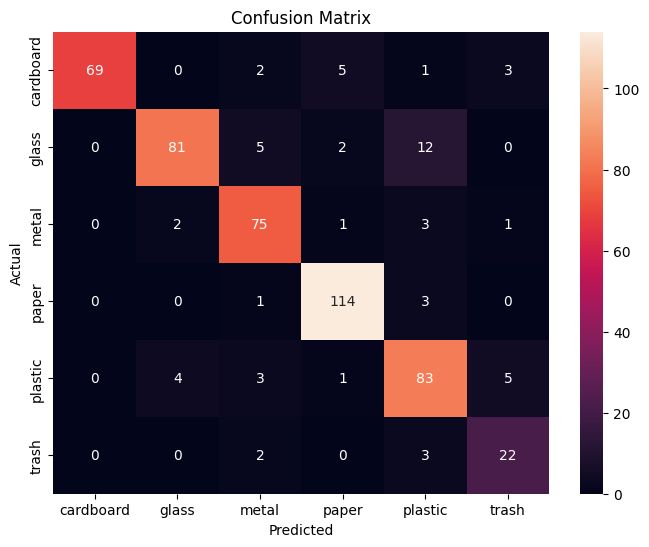

In [ ]:
pred_eff = model_eff.predict(val_data)
y_pred_eff = np.argmax(pred_eff, axis=1)
y_true_eff = val_data.classes

accuracy_eff = accuracy_score(y_true_eff, y_pred_eff)
precision_eff = precision_score(y_true_eff, y_pred_eff, average="weighted")
recall_eff = recall_score(y_true_eff, y_pred_eff, average="weighted")
f1_eff = f1_score(y_true_eff, y_pred_eff, average="weighted")

print(f"\nAccuracy: {accuracy_eff:.4f}")
print(f"Precision: {precision_eff:.4f}")
print(f"Recall: {recall_eff:.4f}")
print(f"F1-Score: {f1_eff:.4f}")

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

plt.figure(figsize=(8,6))
sns.heatmap(cm_eff, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
base_model_eff.trainable = True

for layer in base_model_eff.layers[:-20]:
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_eff.fit(train_data, validation_data=val_data, epochs=5)


In [ ]:
# Save final model (Streamlit-ready)
model_eff.save(
    "eff_model.keras",
    include_optimizer=False
)

print("Model saved as eff_model.keras")


Model saved as eff_model.keras


In [ ]:
import tensorflow as tf
print(tf.__version__)


2.19.0


In [ ]:
model = tf.keras.models.load_model("final_model.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
